### Diffusion diff car controll model  
with DINOv2  
Loss 目安  
実用ラインの目安: 0.005 以下（できれば 0.001 ～ 0.002 付近）


In [1]:
import os
# torchをインポートする前に設定
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import os
import sys
from pathlib import Path

#export PYTHONPATH=$PYTHONPATH:/home/nishi/local/git-download/lerobot/src
# パスを通す（お使いの環境に合わせて絶対パスに書き換えてください）
# git clone をした、パスを使ってください。
lerobot_path = "/home/nishi/local/git-download/lerobot"
sys.path.append(os.path.join(lerobot_path, "src"))

import torch
import torch.nn as nn
import torchvision.models as models
#from diffusers.models.unets.unet_1d import UNet1DModel

from diffusers.schedulers.scheduling_ddim import DDIMScheduler

# 学習時のハイパーパラメータ
BATCH_SIZE = 32          # 8GBに収めるため32（エラーなら16）に設定
#NUM_EPOCHS = 50
#NUM_EPOCHS = 2
#NUM_EPOCHS = 8
NUM_EPOCHS = 14

# tarin を、継続するには、True
cont_f=True

IMAGE_SIZE = (224, 224)  # 画像は224x224にリサイズしてVRAMを節約

ex_trans=True



In [3]:
#%%writefile DiffCarPolicy_dinov2.py
import torch
import torch.nn as nn
import torchvision.models as models
#from diffusers.models.unets.unet_1d import UNet1DModel

#from diffusers.schedulers.scheduling_ddim import DDIMScheduler
# 公式リポジトリなどからConditionalUnet1Dのクラスをインポート（または自作）
#from diffusers.models.embeddings import TimestepEmbedding

# ─── 拡散モデル用の最小限の1D-UNetブロック ───
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super().__init__()
        self.blocks = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.Mish(),
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels)
        )
        # 条件ベクトル（時間＋画像＋ゴール）を各ブロックに染み込ませるための層
        self.cond_mlp = nn.Sequential(
            nn.Mish(),
            nn.Linear(cond_dim, out_channels)
        )
        self.residual_conv = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.final_act = nn.Mish()

    def forward(self, x, cond):
        out = self.blocks[0](x)
        # 条件を時間軸方向に拡張して足し算
        c = self.cond_mlp(cond).unsqueeze(-1)
        out = self.final_act(self.blocks[1:](out + c) + self.residual_conv(x))
        return out

# ─── メインのポリシーネットワーク ───
# ─── メインのポリシーネットワーク (DINOv2 凍結版) ───
class DiffCarPolicy(nn.Module):
    def __init__(self, obs_horizon=2, pred_horizon=16):
        super().__init__()
        self.obs_horizon = obs_horizon
        self.pred_horizon = pred_horizon
        
        # 🌟 1. 画像特徴量抽出用：DINOv2 (ViT-S/14) のロードと完全凍結 🌟
        # Meta公式リポジトリから、屋外の幾何学把握に強い「dinov2_vits14」をダウンロード
        # ※初回実行時のみ、インターネットから自動で重みファイルがダウンロードされます。
        self.vision_encoder = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        
        # DINOv2のパラメータを完全に固定（Train時も一切学習させず、目として使うだけにする）
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
            
        # dinov2_vits14 の出力する特徴ベクトルは「384次元」です
        # (もしより巨大な dinov2_vitb14 を使う場合は 768次元 になります)
        self.dinov2_feature_dim = 384
        
        # 2. 目的地座標 [dx, dy] の処理用 -> 64次元 (変更なし)
        self.goal_encoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )
        
        # 🌟 画像(384) + ゴール(64) = 448次元 * 2フレーム = 896次元 に自動計算
        self.cond_dim = (self.dinov2_feature_dim + 64) * obs_horizon
        
        # タイムステップ（時間情報）を埋め込む層 -> 128次元 (変更なし)
        self.time_encoder = nn.Sequential(
            nn.Linear(1, 128),
            nn.Mish(),
            nn.Linear(128, 128)
        )
        
        # 🌟 統合された条件の総次元数: 896 + 128 = 1024次元 に自動計算
        total_cond_dim = self.cond_dim + 128
        
        # 3. 完全自作の1D-UNet構造 (total_cond_dimに合わせて自動追従するため変更なし)
        self.down1 = ResidualBlock1D(2, 128, total_cond_dim)
        self.down2 = ResidualBlock1D(128, 256, total_cond_dim)
        self.mid = ResidualBlock1D(256, 512, total_cond_dim)
        self.up1 = ResidualBlock1D(512 + 256, 128, total_cond_dim)
        self.up2 = ResidualBlock1D(128 + 128, 64, total_cond_dim)
        
        self.final_layer = nn.Conv1d(64, 2, kernel_size=1) 
        
    def forward(self, noisy_actions, timesteps, image, goal_vector):
        B, _, T = noisy_actions.shape
        O = self.obs_horizon
        
        # 1. 画像とゴールから特徴量を抽出
        C, H, W = image.shape[2:]
        
        # 🌟 DINOv2による特徴量抽出（勾配計算を完全にオフにして高速化）
        with torch.no_grad():
            # 画像を [B*O, C, H, W] に展開してDINOv2に入力
            # 出力形状: [B*O, 384] -> これを元の時系列形状 [B, O, 384] に戻す
            img_features = self.vision_encoder(image.view(B*O, C, H, W)).view(B, O, self.dinov2_feature_dim)
            
        # ゴール特徴量の抽出 [B, O, 64]
        goal_features = self.goal_encoder(goal_vector.view(B*O, 2)).view(B, O, 64) 
        
        # 特徴量のフラット化 [B, 896]
        cond_flat = torch.cat([img_features, goal_features], dim=-1).view(B, -1) 
        
        # 2. 時間情報を埋め込み [B, 128]
        time_features = self.time_encoder(timesteps.unsqueeze(-1).float())
        
        # 3. すべての条件を一本に統合 [B, 1024]
        global_cond = torch.cat([cond_flat, time_features], dim=-1)
        
        # 4. UNetのフォワード処理（スキップ接続付き）
        d1 = self.down1(noisy_actions, global_cond) 
        d2 = self.down2(d1, global_cond)           
        m = self.mid(d2, global_cond)               
        u1 = self.up1(torch.cat([m, d2], dim=1), global_cond)  
        u2 = self.up2(torch.cat([u1, d1], dim=1), global_cond) 
        
        # 5. 予測されたノイズを出力
        noise_pred = self.final_layer(u2) 
        
        return noise_pred


In [4]:
#%%writefile ResizeWithPadTensor.py
import torch
import torch.nn.functional as F
class ResizeWithPadTensor:
    def __init__(self, size=(224,224)):
        self.target_h = size[0]
        self.target_w = size[1]
    def __call__(self, img):
        # --------------------------------
        # img:
        # [B,C,H,W]
        # --------------------------------
        B, C, H, W = img.shape
        # --------------------------------
        # scale
        # --------------------------------
        scale = min(
            self.target_w / W,
            self.target_h / H
        )
        new_w = int(W * scale)
        new_h = int(H * scale)
        # --------------------------------
        # resize
        # --------------------------------
        img = F.interpolate(
            img,
            size=(new_h, new_w),
            mode="bilinear",
            align_corners=False
        )
        # --------------------------------
        # padding size
        # --------------------------------
        pad_left = (self.target_w - new_w) // 2
        pad_right = self.target_w - new_w - pad_left
        pad_top = (self.target_h - new_h) // 2
        pad_bottom = self.target_h - new_h - pad_top
        # --------------------------------
        # pad
        # F.pad order:
        # (left,right,top,bottom)
        # --------------------------------
        img = F.pad(
            img,
            (
                pad_left,
                pad_right,
                pad_top,
                pad_bottom
            ),
            value=0
        )
        return img

#### LeRobot Datsets を使って、data set を作成します。  


In [5]:
import os
import torch
from torch.utils.data import Dataset
from lerobot.datasets.lerobot_dataset import LeRobotDataset

class DiffCarDataset(Dataset):
    def __init__(self, dataset_dir, obs_horizon=2, pred_horizon=16,ex_trans=False):
        self.obs_horizon = obs_horizon
        self.pred_horizon = pred_horizon
        
        # 🌟 あなたが気づいた「最高の機能」をここに適用します！
        # 15Hz（1秒に15フレーム）を想定し、未来16ステップ分のアクションを1発で取る設定
        # 過去2フレーム分の画像も同様にdelta_timestampsで一発で取得します
        delta_cfg = {
            # 過去の画像とステート： [t-1, t] を取得
            "observation.images": [i / 15.0 for i in range(-obs_horizon + 1, 1)],
            "observation.state": [i / 15.0 for i in range(-obs_horizon + 1, 1)],
            # 未来のアクション： [t, t+1, ... t+15] を一括取得
            "action": [i / 15.0 for i in range(pred_horizon)]
        }
        
        # LeRobotDatasetを、delta_timestamps付きでロード
        #self.lerobot_dataset = LeRobotDataset(root_dir=dataset_dir, delta_timestamps=delta_cfg)
        self.lerobot_dataset = LeRobotDataset("motion",root=dataset_dir, delta_timestamps=delta_cfg)
        
        self.resize=ResizeWithPadTensor()
        self.ex_trans=ex_trans

        # 有効なフレームインデックスの計算
        self.indices = []
        for ep_idx in range(self.lerobot_dataset.num_episodes):
            ep_meta = self.lerobot_dataset.meta.episodes[ep_idx]
            #start_frame = ep_meta['start_frame']
            # このエピソードが全体の中のどこから始まるかを計算 (1回400フレーム)
            start_frame = int(self.lerobot_dataset.meta.episodes["dataset_from_index"][ep_idx])

            #end_frame = ep_meta['end_frame']
            end_frame = int(self.lerobot_dataset.meta.episodes["dataset_to_index"][ep_idx])

            num_frames = end_frame - start_frame
            
            # 過去バッファと未来予測の余白が綺麗に取れるインデックスだけを抽出
            start_min = obs_horizon - 1
            start_max = num_frames - pred_horizon
            
            for t in range(start_min, start_max + 1):
                self.indices.append(start_frame + t)
                
        print(f"🚀 [真・LeRobotインジェクター] 初期化完了！総サンプル数: {len(self.indices)} (メモリ消費量: 0 MB)")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # 基準となるフレーム(t)の絶対インデックスを取得
        t = self.indices[idx]
        
        # 🌟 🌟 🌟 ここが劇的にシンプル＆爆速になります 🌟 🌟 🌟
        # delta_timestampsを設定しているため、dataset[t] を1回叩くだけで、
        # 過去2枚の画像、過去2個のゴール、未来16個のアクションが、
        # 内部で「未来の画像をデコードする無駄な処理」を1ミリも挟まずに、完璧な形状で返ってきます！
        frame_data = self.lerobot_dataset[t]
        
        # 1. 過去2フレームの画像 [2, 3, H:224, W:224]
        image_tensor = frame_data["observation.images"].float()
        
        # 2. 過去2フレームのゴールベクトル [2, 2] （20m割りのノーマライズ！）
        goal_tensor = frame_data["observation.state"].float() / 20.0
        
        # 3. 未来16ステップのアクション [16, 2]
        action_tensor = frame_data["action"].float()

        # 🌟 あなたのリサイズクラスの適用（必要に応じて有効化）
        image_tensor = self.resize(image_tensor)
        
        if self.ex_trans:
            # ImageNet標準の平均と標準偏差で画像をノーマライズ
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
            image_tensor = (image_tensor - mean) / std
        
        return {
            'image': image_tensor,
            'goal': goal_tensor,
            'action': action_tensor
        }

In [6]:
import torch
import torchvision.transforms as transforms

# カスタムセピア変換（Tensor[C, H, W]用、値は0.0〜1.0を想定）
def sepia_transform_tensor(img_tensor):
    """
    あらゆる形状 [..., C, H, W] のテンソルに対応したセピア変換
    """
    # 1. チャンネル次元(dim=-3)でRGBを分離
    # これにより、[B, T, 3, H, W] や [B, 3, H, W] から確実に R, G, B を取り出せます
    r, g, b = img_tensor.unbind(dim=-3)
    
    # 2. セピア変換の係数を適用
    # matrixの値を直接個別に掛け合わせることで、形状の不一致を防ぎます
    sepia_r = r * 0.393 + g * 0.769 + b * 0.189
    sepia_g = r * 0.349 + g * 0.686 + b * 0.168
    sepia_b = r * 0.272 + g * 0.534 + b * 0.131
    
    # 3. 再びチャンネル次元(dim=-3)で結合し、0.0〜1.0の範囲にクリップ
    sepia_tensor = torch.stack([sepia_r, sepia_g, sepia_b], dim=-3)
    return torch.clamp(sepia_tensor, 0.0, 1.0)


In [7]:
#from lerobot.datasets.v3.transforms import ColorJitter, SharpnessJitter
from torchvision import transforms
train_transform = transforms.Compose([
    # ====================================================
    # 【注目】以下のリストの中から、毎ステップ「どれか1つだけ」が選ばれます
    # ====================================================
    transforms.RandomChoice([
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.05
        ),
        # 選択肢②：ガウシアンぼかし（RandomApplyを外して確実に実行）
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
        # 選択肢③：セピア色変換
        transforms.Lambda(sepia_transform_tensor),
        # 選択肢④（おまけ）：何もしない（「無変換」のステップも作りたい場合に追加）
        transforms.Lambda(lambda x: x)
    ]),
    # ====================================================
    # normalize
    #transforms.Normalize(
    #    mean=[0.485,0.456,0.406], # 赤・緑・青の平均値
    #    std=[0.229,0.224,0.225]   # 標準偏差
    #)

    # 🌟 ここを DINOv2 の公式指定値に変更します 🌟
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])


In [8]:

# train.py 内での記述例
from torch.utils.data import DataLoader
#from dataset import DiffCarDataset

#data_set_path="./outputs/tugbot_nav2_imitation_2_tf"
data_set_path="outputs/tugbot_nav2_imitation_3_tf_diff"

# 1. データセットの初期化
dataset = DiffCarDataset(
    dataset_dir=data_set_path, 
    obs_horizon=2,       # 過去2フレーム（現在含む）を入力
    pred_horizon=16,      # 未来16ステップ（約1.6秒先まで）を予測
    ex_trans=ex_trans
)

# 2. DataLoader の作成（GTX 1070用にバッチサイズを 32 に設定）
train_loader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE,       # VRAM 8GBに収めるための最適値。これでも重ければ 16 に下げる
    shuffle=True,        # データをシャッフルして学習を安定させる
    #num_workers=2,        # データ読み込みの並列スレッド数
    num_workers=0,
    pin_memory=True      # GPUへのデータ転送を高速化
)

# 3. 学習ループ内での取り出しテスト
for batch in train_loader:
    # データをGPUに転送
    images = batch['image'].to('cuda') # [32, 2, 3, 224, 224]
    goals = batch['goal'].to('cuda')   # [32, 2, 2]
    actions = batch['action'].to('cuda') # [32, 16, 2]
    
    print("バッチのデータ形状:")
    print("画像の形状:", images.shape)
    print("ゴールの形状:", goals.shape)
    print("アクション（速度）の形状:", actions.shape)
    
    break # テストのため1ループで抜ける

🚀 [真・LeRobotインジェクター] 初期化完了！総サンプル数: 33578 (メモリ消費量: 0 MB)
バッチのデータ形状:
画像の形状: torch.Size([32, 2, 3, 224, 224])
ゴールの形状: torch.Size([32, 2, 2])
アクション（速度）の形状: torch.Size([32, 16, 2])


type(img): <class 'torch.Tensor'>
img.shape: torch.Size([224, 224, 3])
img.min(): tensor(0.)  img.max(): tensor(0.9993)


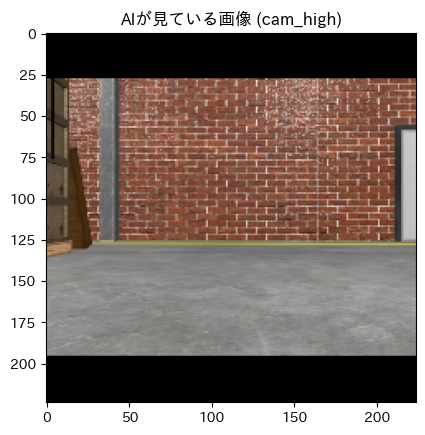

In [9]:
import matplotlib.pyplot as plt
import japanize_matplotlib # これを足すだけで日本語が使えるようになります
import torch

for batch in train_loader:
    # データをGPUに転送
    bt = batch['image'].to('cpu') # [32, 2, 3, 224, 224]
    if not ex_trans:
        n_image=bt
        # テンソルをデータ拡張用にフラット化して適用
        B, T, C, H, W = n_image.shape
        n_image_flat = n_image.view(B * T, C, H, W)
        
        # データ拡張を適用（※0〜1に正規化されているか、0〜255の初期状態かによって挙動が変わるため注意）
        n_image_augmented_flat = train_transform(n_image_flat)
        #_,C, H, W = n_image_augmented_flat.shape
        #print('n_image_augmented_flat.shape:',n_image_augmented_flat.shape)
        # 元のShapeに戻してモデルに入力
        bt = n_image_augmented_flat.view(B, T, C, H, W)

    
    img_tensor = bt[0, 0] # [3, 224, 224] のノーマライズ済みテンソル

    # 🌟 追加: 表示のために逆標準化 (stdを掛けて、meanを足す)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_unnorm = (img_tensor * std) + mean # 0.0 〜 1.0 の範囲に戻る
    
    # Matplotlib用に [224, 224, 3] に転置
    img = img_unnorm.permute(1, 2, 0)
    
    print('type(img):',type(img))
    # model inputs は、(3,480,640) で、色順は、RGB です。
    # plt.imshow()は、デフォルトでRGB（赤・緑・青）の順序 なので、 model の入力も RGB のままです。
    # 2. 画像を表示してみる (PyTorchの [C, H, W] 形式を pillow.show 用の [H, W, C] に変換)
    #img = frame["observation.images.top"].permute(1, 2, 0)
    print('img.shape:',img.shape)  # img.shape: torch.Size([480, 640, 3]) これは、あくまで、pillow 用です。
    print('img.min():',img.min(),' img.max():',img.max())
    plt.imshow(img)
    plt.title("AIが見ている画像 (cam_high)")
    plt.show()
    break # テストのため1ループで抜ける


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用デバイス: {device}")

# データセットとローダーの準備
#dataset = DiffCarDataset(dataset_dir=data_set_path, obs_horizon=2, pred_horizon=16)
#train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

# モデルと最適化アルゴリズムの初期化
policy = DiffCarPolicy(obs_horizon=2, pred_horizon=16).to(device)
optimizer = torch.optim.AdamW(policy.parameters(), lr=1e-4, weight_decay=1e-6)

# 拡散モデルのノイズスケジューラー（DDIMを採用）
noise_scheduler = DDIMScheduler(
    num_train_timesteps=100,
    beta_schedule='squaredcos_cap_v2',
    clip_sample=True,
    prediction_type='epsilon' # ノイズそのものを予測する設定
)

out_dir="./output/train_diff_dinov2"

# ログ保存用フォルダ
#os.makedirs("./checkpoints", exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

best_path = os.path.join(out_dir, "best_model.pth")

print("トレーニングを開始します...")
num_epochs = NUM_EPOCHS # サンプル数が1220件なので、まずは50〜100エポック程度で様子見
global_step = 0 # 🌟 追加: 通算のステップ（バッチ処理）数カウンター

batch_size=BATCH_SIZE
if batch_size==32:
    #check_steps=100
    check_steps=500
elif batch_size==8:
    #check_steps=2500
    check_steps=1000
elif batch_size==4:
    check_steps=5000
else:
    check_steps=10000

step_best_loss = float('inf')


if cont_f:
    latest_check_pth=os.path.join(out_dir, "latest_checkpoint.pt")
    print('latest_check_pth:',latest_check_pth)
    #再開
    checkpoint = torch.load(
        #"checkpoint_50000.pt",
        latest_check_pth,
        map_location=device
    )
    global_step = checkpoint["step"]
    #if global_step >= 50000:
    #    base_lr= 3e-6
    #optimizer = optim.AdamW(model.parameters(), lr=base_lr)
    #model.load_state_dict(torch.load(os.path.join(out_dir, "latest_model.pth")))
    policy.load_state_dict(
        checkpoint["model"]
    )
    optimizer.load_state_dict(
        checkpoint["optimizer"]
    )
    policy = policy.to(device) # SOS, EOS, PADを含めて52クラス
    print(F'load model weight')

policy.train()

for epoch in range(num_epochs):
    policy.train()
    epoch_loss = 0.0
    
    for batch in train_loader:
        # データをGPUへ
        n_image = batch['image'].to(device)
        torch.cuda.empty_cache()

        if not ex_trans:
            #n_image = train_transform(n_image)
    
            # テンソルをデータ拡張用にフラット化して適用
            B, T, C, H, W = n_image.shape
            n_image_flat = n_image.view(B * T, C, H, W)
            
            # データ拡張を適用（※0〜1に正規化されているか、0〜255の初期状態かによって挙動が変わるため注意）
            n_image_augmented_flat = train_transform(n_image_flat)
            #_,C, H, W = n_image_augmented_flat.shape
            #print('n_image_augmented_flat.shape:',n_image_augmented_flat.shape)
            # 元のShapeに戻してモデルに入力
            n_image = n_image_augmented_flat.view(B, T, C, H, W)
        
        n_goal = batch['goal'].to(device)
        gt_action = batch['action'].to(device) # 人間のお手本アクション [B, 16, 2]
        
        B = gt_action.shape[0]
        
        # ① お手本アクションに混ぜる「純粋なノイズ」を生成
        noise = torch.randn_like(gt_action)
        
        # ② 各バッチに対してランダムなタイムステップ（0〜99）を選択
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (B,), device=device).long()
        
        # ③ お手本アクションにノイズをスケジュール通りに混ぜる (順方向拡散)
        # 1D-UNetの仕様 [B, チャンネル, 時間軸] に合わせるため転置
        gt_action_t = gt_action.transpose(1, 2) # [B, 2, 16]
        noise_t = noise.transpose(1, 2)         # [B, 2, 16]
        
        noisy_actions = noise_scheduler.add_noise(gt_action_t, noise_t, timesteps)
        
        # ④ モデル（AI）に「このノイズまみれのアクションから、混ぜられたノイズを当ててみろ」と要求
        pred_noise_t = policy(noisy_actions, timesteps, n_image, n_goal)
        
        # ⑤ 実際のノイズと、AIが予測したノイズの間の誤差（MSE Loss）を計算
        loss = nn.functional.mse_loss(pred_noise_t, noise_t)
        
        # ⑥ 逆伝播とウェイト更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        global_step += 1 # 🌟 追加: 1バッチ処理するたびに加算

        # 🌟 🌟 🌟 【大改造】指定ステップ（例: 200ステップ）ごとに画面にLossを表示する 🌟 🌟 🌟
        #if global_step % 200 == 0:
        if global_step % 100 == 0:
            print(f"Step {global_step} (Epoch {epoch+1}) - Current Batch Loss: {loss.item():.6f}")

            if global_step > 1 and loss < step_best_loss and loss < 0.02 and loss >= 0.001:
                step_best_loss = loss
                torch.save(policy.state_dict(), best_path)
                print(f"Model saved! (Step Best Loss: {step_best_loss:.4f})")

        
        if global_step % check_steps == 0:
            checkpoint = {
                "model": policy.state_dict(),
                "optimizer": optimizer.state_dict(),
                "step": global_step,
            }
            check_pth=os.path.join(out_dir, f"checkpoint_{global_step}.pt")
            latest_check_pth=os.path.join(out_dir, "latest_checkpoint.pt")
            torch.save(
                checkpoint,
                #"checkpoint_50000.pt"
                check_pth
            )
            torch.save(
                checkpoint,
                #"checkpoint_50000.pt"
                latest_check_pth
            )
            print(f"checkpoint saved! (checkpoint_{global_step}.pt)")
    
    # エポック終了時の平均ロス表示
    print(f"Epoch [{epoch+1}/{num_epochs}] Finished - Average Loss: {epoch_loss / len(train_loader):.6f}")
    
    # 10エポックごとにモデルを保存
    #if (epoch + 1) % 10 == 0:
    if (epoch + 1) % 4 == 0:
        save_path=os.path.join(out_dir, f"checkpoint_{epoch+1}.pth")
        torch.save(policy.state_dict(), save_path)
        latest_save_path=os.path.join(out_dir, f"checkpoint_latest.pth")
        torch.save(policy.state_dict(), latest_save_path)
        print(f"➔ モデルを保存しました: {save_path}")
        

使用デバイス: cuda


Using cache found in /home/nishi/.cache/torch/hub/facebookresearch_dinov2_main
/home/nishi/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/nishi/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/nishi/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


トレーニングを開始します...
latest_check_pth: ./output/train_diff_dinov2/latest_checkpoint.pt
load model weight
Step 8100 (Epoch 1) - Current Batch Loss: 0.020277


In [ ]:
latest_path = os.path.join(out_dir, "latest_model.pth")
# --- 5. 最後にモデルを保存 (Final Model) ---
torch.save(policy.state_dict(), latest_path)
print(f"最終モデルを保存しました: {latest_path}")


In [ ]:
if True:
    checkpoint = {
            "model": policy.state_dict(),
            "optimizer": optimizer.state_dict(),
            "step": global_step,
        }
    latest_check_pth=os.path.join(out_dir, "latest_checkpoint.pt")
    torch.save(
        checkpoint,
        #"checkpoint_50000.pt"
        latest_check_pth
    )
    print(f"checkpoint saved! (checkpoint_{global_step}.pt)")
